# AGFB Metric Behavior Check

This notebook is a small behavioral smoke test for the Analytic Gradient Filter
Benchmark (AGFB) metrics. The metrics in `agfb-metrics` score a predicted
gradient field against a ground-truth gradient field, so unlike the generator
and noise notebooks there is no single image to look at. Instead the notebook
answers three questions. First, can each metric be computed with a short,
readable call. Second, does a perfect prediction score at the ideal value for
every metric. Third, when the prediction is degraded in one controlled way,
does the matching metric move in the expected direction while the others stay
put.

The pattern throughout is to synthesize an analytic ground-truth gradient field,
build a degraded prediction from it, derive the standard masks, and call
`evaluate_all_metrics`. Every field here is created with plain `torch`, so the
notebook depends only on `agfb_metrics` and a Jupyter kernel.

## Setup

Run this cell first. It imports the metric API and the notebook display helpers, picks a device, fixes a seed, and sets a shared canvas size.

In [1]:
%load_ext autoreload
%autoreload 2

import math

import torch

from agfb_metrics.metrics import (
    PIXEL_METRICS,
    MetricEvaluator,
    evaluate_all_metrics,
    evaluate_metrics,
    is_triton_pixel_available,
    masks,
)
from agfb_metrics.notebook import (
    metric_table,
    setup_notebook,
    show_color_scheme,
    show_images,
    show_table,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)

H, W = 128, 128  # Shared canvas for every field in the notebook.
setup_notebook(height=H, width=W)

python,3.13.13
platform,macOS-15.7.1-arm64-arm-64bit-Mach-O
cpu cores,10
torch,2.6.0
cuda available,False
cuda device,not available
render size,128x128
helper path,/Users/user/Documents/New project/AGFB/agfb-metrics/agfb_metrics/notebook.py


## Color Scheme

The display helpers reuse the AGFB brand palette. Intensity uses a garnet ramp, gradient magnitude uses a warm ramp, signed channels use a diverging rose-to-atlantic ramp, and masks use a single accent color.

In [2]:
show_color_scheme()

role,legend,stops,used for
intensity,,"0.00: #000000, 0.55: #73000A, 1.00: #FFFFFF",Scalar image values.
magnitude,,"0.00: #000000, 0.72: #A49137, 1.00: #FFFFFF",Nonnegative gradient magnitude values.
signed,,"0.00: #CC2E40, 0.50: #FFFFFF, 1.00: #466A9F",Signed fields such as g_x or g_y.
mask,,"0.00: #000000, 1.00: #CED318",Boolean or binary masks.


## Ground-Truth Field

The truth field is a smoothed step edge. Along the edge normal `n`, the
intensity is an error-function step and its analytic derivative is a Gaussian
profile of width `edge_sigma`. The gradient points along `n`, so
`g_x = profile * cos(theta)` and `g_y = profile * sin(theta)`.

`analytic_step` returns the intensity and the two gradient channels for one
angle. The optional `lobe` and `lobe_sep` arguments add symmetric secondary
bumps to the magnitude profile without changing its direction, which is used
later to build a prediction with ringing side lobes. The truth field uses
`lobe=0`.

A realistic `amplitude` of 255 keeps every signal pixel well above the
relative mask threshold, so direction-based metrics are numerically clean on a
perfect prediction.

In [3]:
AMPLITUDE = 255.0


def analytic_step(angle_rad, edge_sigma, *, lobe=0.0, lobe_sep=0.0, amplitude=AMPLITUDE):
    ys = torch.arange(H, dtype=torch.float32) - (H - 1) / 2
    xs = torch.arange(W, dtype=torch.float32) - (W - 1) / 2
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")
    n_x, n_y = math.cos(angle_rad), math.sin(angle_rad)
    s = xx * n_x + yy * n_y

    def gauss(u):
        return torch.exp(-(u**2) / (2 * edge_sigma**2))

    scale = amplitude / (edge_sigma * math.sqrt(2 * math.pi))
    profile = scale * (gauss(s) + lobe * gauss(s - lobe_sep) + lobe * gauss(s + lobe_sep))
    intensity = amplitude * 0.5 * (1 + torch.erf(s / (edge_sigma * math.sqrt(2))))
    return intensity, profile * n_x, profile * n_y


# A small batch of three edge orientations so each score is a mean over angles.
angles = [math.radians(0), math.radians(30), math.radians(60)]
truth = [analytic_step(a, edge_sigma=3.0) for a in angles]

intensity = torch.stack([item[0] for item in truth]).to(device)
g_x_t = torch.stack([item[1] for item in truth]).to(device)
g_y_t = torch.stack([item[2] for item in truth]).to(device)

g_x_t.shape, g_x_t.dtype, g_x_t.device

(torch.Size([3, 128, 128]), torch.float32, device(type='cpu'))

The first batch item shows the intensity, the two signed gradient channels, and the gradient magnitude. The magnitude is a thin Gaussian ridge centered on the edge.


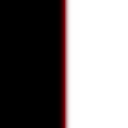


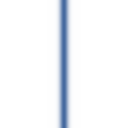
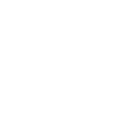


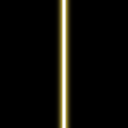

In [4]:
mag_t = torch.sqrt(g_x_t**2 + g_y_t**2)
show_images([(intensity[0], "intensity")], kind="intensity")
show_images(
    [(g_x_t[0], "g_x truth"), (g_y_t[0], "g_y truth")],
    title="truth gradient channels",
    signed=True,
)
show_images([(mag_t[0], "|grad| truth")], title="truth gradient magnitude", kind="magnitude")

## Masks

`masks(g_x_t, g_y_t)` builds both region masks from the truth field. The signal
mask marks pixels where the true gradient magnitude is present, and the flat
mask marks background pixels eroded inward so no flat pixel sits inside the
support of an edge. Signal-region metrics score the ridge, and flat-region
metrics score the quiet background.


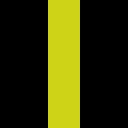
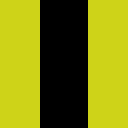

signal fraction: 0.273
flat fraction:   0.556


In [5]:
mask_dict = masks(g_x_t, g_y_t)
signal_mask = mask_dict["signal"]
flat_mask = mask_dict["flat"]

show_images(
    [(signal_mask[0].float(), "signal mask"), (flat_mask[0].float(), "flat mask")],
    title="region masks",
    kind="mask",
)
print(f"signal fraction: {signal_mask.float().mean():.3f}")
print(f"flat fraction:   {flat_mask.float().mean():.3f}")

## Predictors

Each predictor is the truth field degraded in one isolated way.

`ideal` copies the truth and should score at the best value for every metric.
`blurred` smooths both channels, which widens the edge. `rotated` turns the
gradient vectors by five degrees, which only changes direction. `scaled`
multiplies the magnitude by `1.2`, which only changes magnitude. `lobed` adds
symmetric side lobes to the magnitude profile while keeping the direction,
which introduces ringing. `noisy` adds independent Gaussian noise to both
channels, which mostly shows up in the flat background.

In [6]:
def gaussian_blur(field, sigma):
    radius = max(1, int(3 * sigma))
    offsets = torch.arange(-radius, radius + 1, dtype=torch.float32, device=field.device)
    kernel = torch.exp(-(offsets**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    x = field.unsqueeze(1)
    x = torch.nn.functional.conv2d(x, kernel.view(1, 1, 1, -1), padding=(0, radius))
    x = torch.nn.functional.conv2d(x, kernel.view(1, 1, -1, 1), padding=(radius, 0))
    return x.squeeze(1)


def rotate(g_x, g_y, degrees):
    angle = math.radians(degrees)
    cos_a, sin_a = math.cos(angle), math.sin(angle)
    return cos_a * g_x - sin_a * g_y, sin_a * g_x + cos_a * g_y


peak_magnitude = float(mag_t.amax())
sigma_n = 0.02 * peak_magnitude  # Noise scale tied to the signal peak.

lobed = [analytic_step(a, edge_sigma=3.0, lobe=0.25, lobe_sep=9.0) for a in angles]
g_x_lobed = torch.stack([item[1] for item in lobed]).to(device)
g_y_lobed = torch.stack([item[2] for item in lobed]).to(device)

torch.manual_seed(0)
predictors = {
    "ideal": (g_x_t.clone(), g_y_t.clone()),
    "blurred": (gaussian_blur(g_x_t, 2.0), gaussian_blur(g_y_t, 2.0)),
    "rotated": rotate(g_x_t, g_y_t, 5.0),
    "scaled": (g_x_t * 1.2, g_y_t * 1.2),
    "lobed": (g_x_lobed, g_y_lobed),
    "noisy": (g_x_t + sigma_n * torch.randn_like(g_x_t), g_y_t + sigma_n * torch.randn_like(g_y_t)),
}

print(f"peak magnitude: {peak_magnitude:.3f}")
print(f"sigma_n:        {sigma_n:.4f}")

peak magnitude: 33.910
sigma_n:        0.6782


The gradient magnitude of each prediction shows the degradation directly. The blurred ridge is wider, the lobed ridge has flanking bumps, and the noisy field has a textured background.


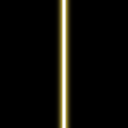
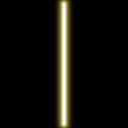
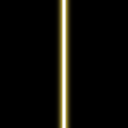
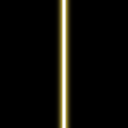
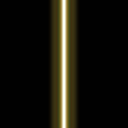
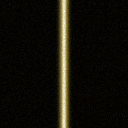

In [7]:
show_images(
    [(torch.sqrt(g_x**2 + g_y**2)[0], name) for name, (g_x, g_y) in predictors.items()],
    title="prediction gradient magnitude",
    kind="magnitude",
)

## Every Metric For Every Predictor

`evaluate_all_metrics` returns one score per image for each of the ten metric
names in `ALL_METRICS`. The table below reports the mean over the three edge
orientations. Read it one row at a time. The `ideal` row is the reference, and
each degraded row should differ from it mainly in the metric that matches its
degradation.

In [8]:
results = {}
for name, (g_x, g_y) in predictors.items():
    scores = evaluate_all_metrics(
        g_x,
        g_y,
        g_x_t,
        g_y_t,
        signal_mask=signal_mask,
        flat_mask=flat_mask,
        sigma_n=sigma_n,
    )
    results[name] = {metric: float(value.mean()) for metric, value in scores.items()}

metric_table(results, title="mean scores over the batch")

predictor,nrmse,angular_mae,tail_vector_error,localization_offset,tangential_normal_leak,magnitude_bias,edge_fwhm,sidelobe_ratio,noise_gain,tail_spurious_grad
ideal,0.0,0.0028,0.0,0.0,-inf,0.0,7.1658,nan,0.0,0.0
blurred,0.2854,0.0031,5.3671,0.033,-inf,-0.0122,8.5786,nan,0.0,0.0
rotated,0.1506,5.0,2.8773,0.0,-21.161,0.0,7.1658,nan,0.0,0.0
scaled,0.3453,0.003,6.5964,0.0032,-inf,0.2,7.1658,nan,0.0,0.0
lobed,0.6102,0.0024,8.3895,0.002,-inf,0.4944,7.7742,-11.2867,0.0,0.0
noisy,0.1202,43.7633,1.6855,0.1947,-26.1064,0.0481,7.1379,-26.0097,0.6509,2.0397


The table reads as designed. The `ideal` prediction scores zero on every error
metric, with `tangential_normal_leak` at negative infinity because a perfectly
aligned prediction leaks no energy into the normal direction. The `blurred`
prediction raises `edge_fwhm`. The `rotated` prediction raises `angular_mae` to
about five degrees and raises `tangential_normal_leak`. The `scaled` prediction
sets `magnitude_bias` to about `0.2` and leaves direction untouched. The `lobed`
prediction is the only one with a finite `sidelobe_ratio`, since a clean
monotone profile has no side lobes to measure. The `noisy` prediction drives
the flat-region metrics `noise_gain` and `tail_spurious_grad`.

## Behavioral Checks

The single-predictor table suggests the right trends. The sweeps below confirm that each metric moves monotonically as its targeted degradation grows.

### Rotation Drives Angular Error

Turning the predicted gradient vectors by a growing angle should raise `angular_mae` by about that angle and steadily raise the tangential-normal leak.

In [9]:
rows = []
for degrees in [0.0, 2.0, 5.0, 10.0, 20.0]:
    g_x_r, g_y_r = rotate(g_x_t, g_y_t, degrees)
    out = evaluate_metrics(
        g_x_r,
        g_y_r,
        g_x_t,
        g_y_t,
        metrics=("angular_mae", "tangential_normal_leak"),
        signal_mask=signal_mask,
        flat_mask=flat_mask,
    )
    rows.append(
        [
            degrees,
            round(float(out["angular_mae"].mean()), 3),
            round(float(out["tangential_normal_leak"].mean()), 3),
        ]
    )

show_table(
    ["rotation (deg)", "angular_mae", "tangential_normal_leak"], rows, title="rotation sweep"
)

rotation (deg),angular_mae,tangential_normal_leak
0.0,0.003,-inf
2.0,2.0,-29.138
5.0,5.0,-21.161
10.0,10.0,-15.074
20.0,20.0,-8.779


### Blur Widens The Edge

Smoothing the gradient with a wider kernel should raise `edge_fwhm` and `nrmse`. The zero-sigma row is the untouched truth.

In [10]:
rows = []
for sigma in [0.0, 1.0, 2.0, 4.0]:
    if sigma == 0.0:
        g_x_b, g_y_b = g_x_t, g_y_t
    else:
        g_x_b, g_y_b = gaussian_blur(g_x_t, sigma), gaussian_blur(g_y_t, sigma)
    out = evaluate_metrics(
        g_x_b,
        g_y_b,
        g_x_t,
        g_y_t,
        metrics=("edge_fwhm", "nrmse"),
        signal_mask=signal_mask,
        flat_mask=flat_mask,
    )
    rows.append(
        [sigma, round(float(out["edge_fwhm"].mean()), 3), round(float(out["nrmse"].mean()), 3)]
    )

show_table(["blur sigma (px)", "edge_fwhm", "nrmse"], rows, title="blur sweep")

blur sigma (px),edge_fwhm,nrmse
0.0,7.166,0.0
1.0,7.547,0.105
2.0,8.579,0.285
4.0,11.858,0.677


### Noise Drives The Flat-Region Metrics

Adding independent Gaussian noise scaled to the signal peak should raise `noise_gain` toward the Rayleigh constant of about `0.655` and raise the flat-region tail `tail_spurious_grad`.

In [11]:
rows = []
for fraction in [0.01, 0.02, 0.05, 0.1, 0.2]:
    scale = fraction * peak_magnitude
    torch.manual_seed(0)
    g_x_n = g_x_t + scale * torch.randn_like(g_x_t)
    g_y_n = g_y_t + scale * torch.randn_like(g_y_t)
    out = evaluate_metrics(
        g_x_n,
        g_y_n,
        g_x_t,
        g_y_t,
        metrics=("noise_gain", "tail_spurious_grad"),
        signal_mask=signal_mask,
        flat_mask=flat_mask,
        sigma_n=scale,
    )
    rows.append(
        [
            fraction,
            round(float(out["noise_gain"].mean()), 3),
            round(float(out["tail_spurious_grad"].mean()), 3),
        ]
    )

show_table(["noise fraction", "noise_gain", "tail_spurious_grad"], rows, title="noise sweep")

noise fraction,noise_gain,tail_spurious_grad
0.01,0.651,1.02
0.02,0.651,2.04
0.05,0.651,5.099
0.1,0.651,10.198
0.2,0.651,20.397


## Reusable Evaluators

`MetricEvaluator` fixes the metric set and settings once and reuses them across
calls, which is the pattern for sweeping many predictions of the same shape.
`evaluate_metrics` is the one-shot form and is convenient for a quick subset.
Both return the same scores as `evaluate_all_metrics` for the metrics they share.

In [12]:
evaluator = MetricEvaluator(metrics=PIXEL_METRICS, sigma_n=sigma_n, use_compile=False)
g_x_noisy, g_y_noisy = predictors["noisy"]
batched = evaluator(
    g_x_noisy, g_y_noisy, g_x_t, g_y_t, signal_mask=signal_mask, flat_mask=flat_mask
)

subset = evaluate_metrics(
    g_x_noisy,
    g_y_noisy,
    g_x_t,
    g_y_t,
    metrics=("nrmse", "angular_mae", "noise_gain"),
    signal_mask=signal_mask,
    flat_mask=flat_mask,
    sigma_n=sigma_n,
)

print("MetricEvaluator (PIXEL_METRICS):")
for name in PIXEL_METRICS:
    print(f"  {name:24s} {float(batched[name].mean()):.4f}")
print("evaluate_metrics subset:")
for name in ("nrmse", "angular_mae", "noise_gain"):
    print(f"  {name:24s} {float(subset[name].mean()):.4f}")

MetricEvaluator (PIXEL_METRICS):
  nrmse                    0.1202
  angular_mae              43.7633
  tail_vector_error        1.6855
  tangential_normal_leak   -26.1064
  magnitude_bias           0.0481
  noise_gain               0.6509
  tail_spurious_grad       2.0397
evaluate_metrics subset:
  nrmse                    0.1202
  angular_mae              43.7633
  noise_gain               0.6509


## Triton Backend And Tail Modes

On Linux with a CUDA GPU the package installs `TritonPixelEvaluator`, a fused
full-image backend for the pixel metrics. It supports an exact tail mode for
reported tables and a histogram tail mode for high-throughput sweeps. The cell
guards on `is_triton_pixel_available()` so the notebook still runs on a CPU-only
machine, where the backend is unavailable and this section is skipped.

In [13]:
if is_triton_pixel_available():
    from agfb_metrics.metrics import TritonPixelEvaluator

    g_x_noisy, g_y_noisy = predictors["noisy"]
    rows = []
    for tail_mode in ("exact", "histogram"):
        evaluator = TritonPixelEvaluator(
            metrics=PIXEL_METRICS, sigma_n=sigma_n, tail_mode=tail_mode
        )
        out = evaluator(g_x_noisy, g_y_noisy, g_x_t, g_y_t, signal_mask=None, flat_mask=None)
        rows.append([tail_mode] + [round(float(out[name].mean()), 4) for name in PIXEL_METRICS])
    show_table(["tail_mode", *PIXEL_METRICS], rows, title="Triton exact vs histogram tails")
else:
    print("Triton pixel backend not available on this machine; section skipped.")
    print("It installs on Linux x86_64 with a CUDA GPU.")

Triton pixel backend not available on this machine; section skipped.
It installs on Linux x86_64 with a CUDA GPU.


This notebook is a behavioral check rather than an exhaustive test. When a new metric is added to the package, it joins `ALL_METRICS` and appears automatically in the per-predictor table, and a matching predictor or sweep can be added alongside the existing ones.

Author: J.C. Vaught.